# Simple Linear Regression

# Importing Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

# Create our own data

In [5]:
# datafile=pd.DataFrame()
# datafile[0]=[1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# datafile[1]=[2.64, 2.59, 2.59, 2.6, 2.55, 2.68, 2.52, 2.79, 2.61, 2.63, 2.63, 2.66, 2.57, 2.48, 2.45, 2.64, 2.48, 2.77, 2.79, 2.81, 2.79, 2.77, 2.57, 2.7, 2.8, 2.68, 2.82, 2.72, 2.69, 2.82, 2.85, 3.28, 2.93]
# datafile.columns=['Year','Goals_Per_Match']
# datafile

df = pd.read_csv('EPL_GoalsPerMatch.csv')
df

,Year,Goals_Per_Match
0,1992,2.64
1,1993,2.59
2,1994,2.59
3,1995,2.60
4,1996,2.55
5,1997,2.68
6,1998,2.52
7,1999,2.79
8,2000,2.61
9,2001,2.63


# Checking linearity

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


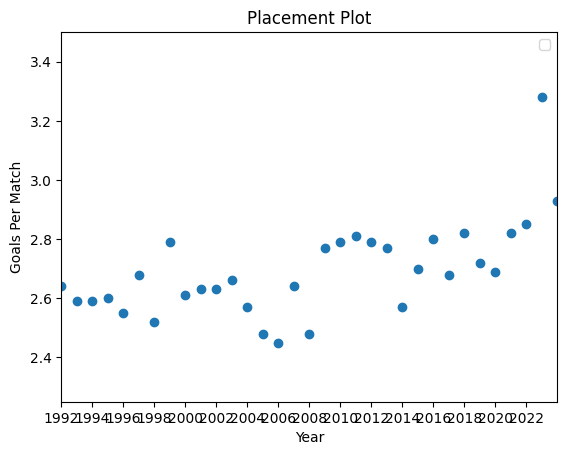

In [6]:
plt.scatter(df['Year'],df['Goals_Per_Match'])
plt.title("Placement Plot")
plt.xlim(1992,2024)
plt.ylim(2.25,3.5)
plt.xticks(np.arange(1992,2024,2))
plt.legend()
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()

<Axes: >

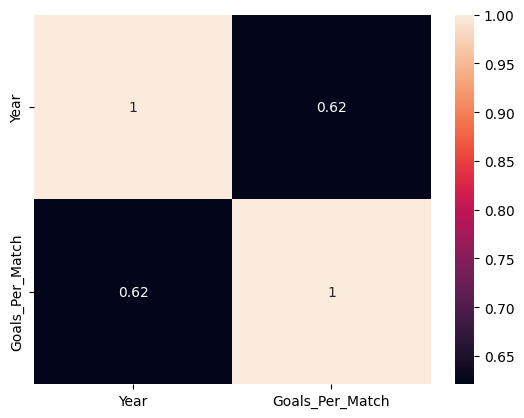

In [8]:
import seaborn as sb
data_corr=df.corr()
sb.heatmap(data_corr,annot=True)

In [9]:
from sklearn import linear_model
regress=linear_model.LinearRegression()
train_x=np.asanyarray(df[['Year']])
train_y=np.asanyarray(df[['Goals_Per_Match']])
#print(train_x)
#print(train_y)
regress.fit(train_x,train_y)
#The coefficients
print('Coefficients:',regress.coef_)
print('Intercept:',regress.intercept_)


Coefficients: [[0.01019385]]
Intercept: [-17.77531194]


# Plotoutputs

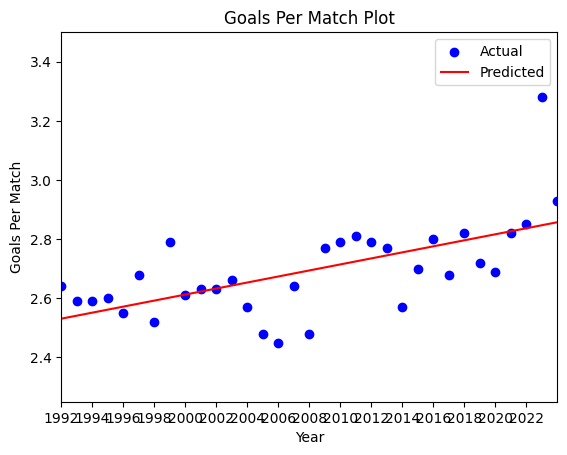

In [11]:
plt.scatter(df.Year,df.Goals_Per_Match,   color='blue',label="Actual")
plt.plot(train_x,regress.coef_[0][0]*train_x+regress.intercept_[0],'-r',label="Predicted")
plt.title("Goals Per Match Plot")
plt.xlim(1992,2024)
plt.ylim(2.25,3.5)
plt.xticks(np.arange(1992,2024,2))
plt.legend()
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()

In [13]:
y_predicted = regress.predict(train_x)
for i in range(0,len(train_x)):
    print(train_y[i],y_predicted[i])
df['Predicted']=y_predicted

print(df.head())
#df.to_csv(r"E:\25MCS1019_Utsav_Dasgupta\ml_lab\lab2\EPL_GoalsPerMatch.csv")

[2.64] [2.53083779]
[2.59] [2.54103164]
[2.59] [2.55122549]
[2.6] [2.56141934]
[2.55] [2.57161319]
[2.68] [2.58180704]
[2.52] [2.59200089]
[2.79] [2.60219474]
[2.61] [2.61238859]
[2.63] [2.62258244]
[2.63] [2.63277629]
[2.66] [2.64297014]
[2.57] [2.65316399]
[2.48] [2.66335784]
[2.45] [2.67355169]
[2.64] [2.68374554]
[2.48] [2.69393939]
[2.77] [2.70413324]
[2.79] [2.71432709]
[2.81] [2.72452094]
[2.79] [2.7347148]
[2.77] [2.74490865]
[2.57] [2.7551025]
[2.7] [2.76529635]
[2.8] [2.7754902]
[2.68] [2.78568405]
[2.82] [2.7958779]
[2.72] [2.80607175]
[2.69] [2.8162656]
[2.82] [2.82645945]
[2.85] [2.8366533]
[3.28] [2.84684715]
[2.93] [2.857041]
   Year  Goals_Per_Match  Predicted
0  1992             2.64   2.530838
1  1993             2.59   2.541032
2  1994             2.59   2.551225
3  1995             2.60   2.561419
4  1996             2.55   2.571613


# Performance Measurement

# Any of the following metrics can be used
1) Mean Absolute error
2) Mean Squared error
3) Root Mean Squared error
4) R-Square (not error)

In [14]:
from sklearn import metrics
print('Mean Absolute error ', metrics.mean_absolute_error(train_y,y_predicted))
print('Mean Squared error ', metrics.mean_squared_error(train_y,y_predicted))
print('Root Mean Squared error ', np.sqrt(metrics.mean_squared_error(train_y,y_predicted)))

Mean Absolute error  0.08614649165451319
Mean Squared error  0.014996225625236306
Root Mean Squared error  0.1224590773492774


In [16]:
from sklearn.metrics import r2_score
test_x=np.asanyarray(df[['Year']])
test_y=np.asanyarray(df[['Goals_Per_Match']])
test_y_predicted=regress.predict(test_x)
print('Mean Absolute error (MAE)', np.mean(np.absolute(test_y_predicted-test_y)))
print('Mean Squared error (MSE)', np.mean(test_y_predicted-test_y)**2)
print('R2 score:%0.2f ', r2_score(test_y,test_y_predicted))


Mean Absolute error (MAE) 0.08614649165451319
Mean Squared error (MSE) 2.1912802922805882e-32
R2 score:%0.2f  0.38584898251730515


# Using Training and Testing Data

In [ ]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y=train_test_split(df[['Year']],df[['Goals_Per_Match']],test_size=0.30)
print(train_x)
print("Testing")
print(test_x)

from sklearn import linear_model
regress=linear_model.LinearRegression()
regress.fit(train_x,train_y)
print('Coefficients:',regress.coef_)
print('Intercept:',regress.intercept_)



    Year
0   1992
28  2020
20  2012
25  2017
3   1995
24  2016
13  2005
27  2019
9   2001
14  2006
21  2013
31  2023
15  2007
5   1997
7   1999
1   1993
23  2015
8   2000
2   1994
22  2014
26  2018
17  2009
32  2024
Testing
    Year
11  2003
18  2010
30  2022
12  2004
29  2021
16  2008
6   1998
10  2002
19  2011
4   1996
Coefficients: [[0.0094087]]
Intercept: [-16.18948951]


In [19]:
y_predicted=regress.predict(test_x)
print(test_x)
print(test_y)
print(y_predicted)


    Year
11  2003
18  2010
30  2022
12  2004
29  2021
16  2008
6   1998
10  2002
19  2011
4   1996
    Goals_Per_Match
11             2.66
18             2.79
30             2.85
12             2.57
29             2.82
16             2.48
6              2.52
10             2.63
19             2.81
4              2.55
[[2.65612854]
 [2.72198941]
 [2.83489377]
 [2.66553724]
 [2.82548507]
 [2.70317202]
 [2.60908506]
 [2.64671985]
 [2.73139811]
 [2.59026767]]


In [31]:
from sklearn import metrics
print("For 70-30 Split")
print('Mean Absolute error ', metrics.mean_absolute_error(test_y,y_predicted))
print('Mean Squared error ', metrics.mean_squared_error(test_y,y_predicted))
print('Root Mean Squared error ', np.sqrt(metrics.mean_squared_error(test_y,y_predicted)))


For 70-30 Split
Mean Absolute error  0.13183219648701916
Mean Squared error  0.025030643290591875
Root Mean Squared error  0.15821075592573305


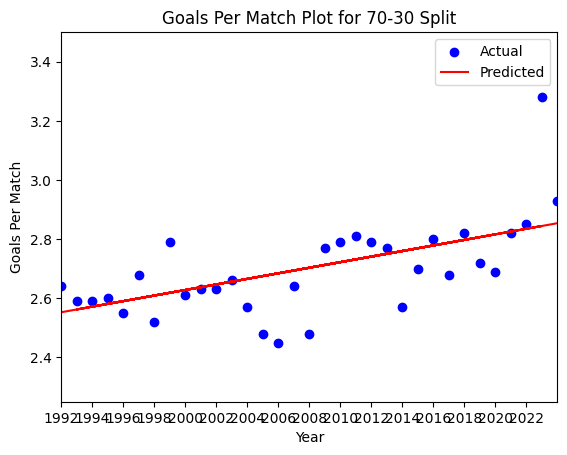

In [22]:
plt.scatter(df.Year,df.Goals_Per_Match,   color='blue',label="Actual")
plt.plot(train_x,regress.coef_[0][0]*train_x+regress.intercept_[0],'-r',label="Predicted")
plt.title("Goals Per Match Plot for 70-30 Split")
plt.xlim(1992,2024)
plt.ylim(2.25,3.5)
plt.xticks(np.arange(1992,2024,2))
plt.legend()
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score
accuracy=cross_val_score(regress,df[['Year']],df[['Goals_Per_Match']],cv=5,scoring='r2')
print(accuracy)

[-4.27125026 -0.45798067  0.14772693 -0.48210158 -0.32529178]


In [32]:
train_x,test_x,train_y,test_y=train_test_split(df[['Year']],df[['Goals_Per_Match']],test_size=0.20)
regress=linear_model.LinearRegression()
regress.fit(train_x,train_y)
y_predicted=regress.predict(test_x)
print("For 80-20 Split")
print('Coefficients:',regress.coef_)
print('Intercept:',regress.intercept_)
print('Mean Absolute error(MAE) ', metrics.mean_absolute_error(test_y,y_predicted))
print('Mean Squared error(MSE) ', metrics.mean_squared_error(test_y,y_predicted))
print('Root Mean Squared error(RMSE) ', np.sqrt(metrics.mean_squared_error(test_y,y_predicted)))


For 80-20 Split
Coefficients: [[0.01064037]]
Intercept: [-18.66792132]
Mean Absolute error(MAE)  0.04889970080809843
Mean Squared error(MSE)  0.004665387942062121
Root Mean Squared error(RMSE)  0.06830364515940654


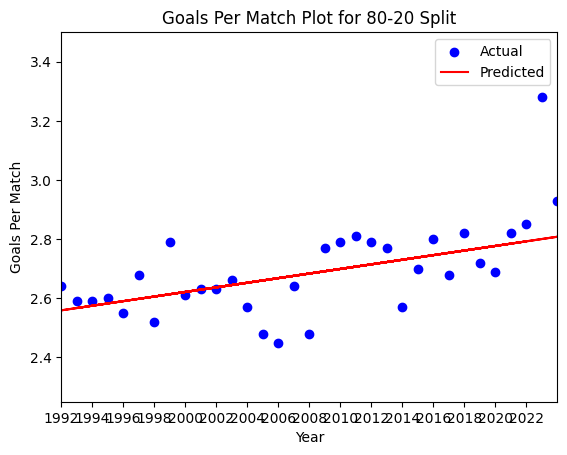

In [26]:
plt.scatter(df.Year,df.Goals_Per_Match,   color='blue',label="Actual")
plt.plot(train_x,regress.coef_[0][0]*train_x+regress.intercept_[0],'-r',label="Predicted")
plt.title("Goals Per Match Plot for 80-20 Split")
plt.xlim(1992,2024)
plt.ylim(2.25,3.5)
plt.xticks(np.arange(1992,2024,2))
plt.legend()
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()

In [ ]:
train_x,test_x,train_y,test_y=train_test_split(df[['Year']],df[['Goals_Per_Match']],test_size=0.10)
regress=linear_model.LinearRegression()
regress.fit(train_x,train_y)
y_predicted=regress.predict(test_x)
print("For 90-10 Split")
print('Coefficients:',regress.coef_)
print('Intercept:',regress.intercept_)
print('Mean Absolute error(MAE) ', metrics.mean_absolute_error(test_y,y_predicted))
print('Mean Squared error(MSE) ', metrics.mean_squared_error(test_y,y_predicted))
print('Root Mean Squared error(RMSE) ', np.sqrt(metrics.mean_squared_error(test_y,y_predicted)))


Coefficients: [[0.01045411]]
Intercept: [-18.28637508]
Mean Absolute error(MAE)  0.13183219648701916
Mean Squared error(MSE)  0.025030643290591875
Root Mean Squared error(RMSE)  0.15821075592573305


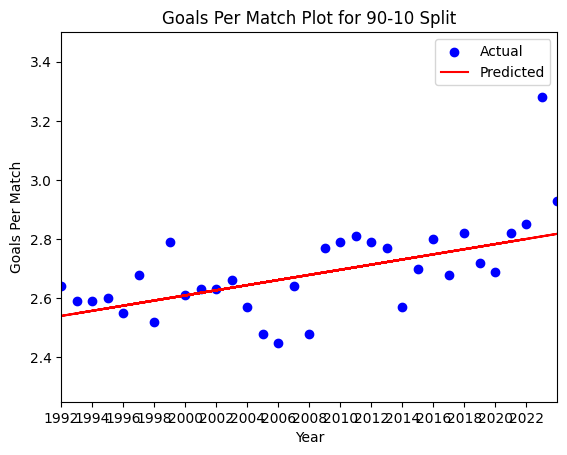

In [28]:
plt.scatter(df.Year,df.Goals_Per_Match,   color='blue',label="Actual")
plt.plot(train_x,regress.coef_[0][0]*train_x+regress.intercept_[0],'-r',label="Predicted")
plt.title("Goals Per Match Plot for 90-10 Split")
plt.xlim(1992,2024)
plt.ylim(2.25,3.5)
plt.xticks(np.arange(1992,2024,2))
plt.legend()
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()